# Bernoulli Probability Distribution

## 1. Definition

A Bernoulli distribution models a single experiment with exactly two possible outcomes. 

## 2. Intuition

**Did one trial succeed or fail?**

## 3. Parameter

The parameter **$\theta$** represents the probability of success, so once θ is known, **the entire distribution is determined**.

## 4. Support

The Bernoulli distribution may be nonzero only for **$y=0$** and **$y=1$**. ( $y \epsilon [0,1]$ )

## 5. Probability Mass Function

$$
f(y;theta) = \theta^{y} + (1 - \theta)^{1-y} =
\begin{cases}
1-\theta, & y=0,\\
\theta, & y=1.
\end{cases}
$$

## 6. Cumulative Distribution Function

$$
F(y;\theta)=
\begin{cases}
0, & y<0,\\
1-\theta, & 0\le y<1,\\
1, & y\ge1.
\end{cases}
$$

## 7. Moments

**Mean**: $\theta$

**Variance**: $\theta(1-\theta)$

## 8. NumPy Implementation

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [35]:
class Bernoulli:
    """
        Bernoulli Distribution with success rate theta.

        Possible Outcomes:
            Y = 0 -> failure
            Y = 1 -> success
    """

    def __init__(self, theta: float):
        if not 0 <= theta <= 1:
            raise ValueError("theta must be between 0 and 1")

        self.theta = float(theta)

    def pmf(self, y):
        """
            Probability Mass Function:

            P(Y=y) = theta^y + (1-theta)^(1-y)

            Valid only for 0 and 1
        """

        y = np.asarray(y)

        P = np.zeros_like(y, dtype=float)

        P[y == 0] = 1 - self.theta
        P[y == 1] = self.theta

        return P

    def cdf(self, y):
        """
            Cumulative Distribution Function:

            F(y) = 0 , y<0
                 = 1 - theta  , 0<y<1
                 = theta , y>1
        """

        y = np.asarray(y)

        return np.where(
            y < 0, 
            0.0,
            np.where(y<1, 1 - self.theta, 1.0)
        )

    def mean(self):
        """
            E[Y] = theta
        """
        return self.theta

    def variance(self):
       """
           Var(Y) = theta * (1-theta)
       """ 

       return self.theta * (1 - self.theta)

    def sample(self, size=1, random_state=None):
        """
            Generate random Bernoulli samples.

            A sample is 1 when a uniform random number is less than theta.
            otherwise, it is 0.
        """

        rng = np.random.default_rng(random_state)

        uniform_samples = rng.random(size)

        return (uniform_samples < self.theta).astype(int)

    def plot(self, figsize=(10, 4)):
        """
        Plot the PMF and CDF of the Bernoulli distribution.
        """
    
        import matplotlib.pyplot as plt
    
        support = np.array([0, 1])
    
        pmf = self.pmf(support)
        cdf = self.cdf(support)
    
        fig, ax = plt.subplots(1, 2, figsize=figsize)
    
        # PMF
        ax[0].stem(support, pmf)
        ax[0].set_title("Bernoulli PMF")
        ax[0].set_xlabel("Outcome")
        ax[0].set_ylabel("Probability")
        ax[0].set_xticks([0, 1])
        ax[0].grid(True)
    
        # CDF
        ax[1].step(support, cdf, where="post")
        ax[1].set_title("Bernoulli CDF")
        ax[1].set_xlabel("Outcome")
        ax[1].set_ylabel("Cumulative Probability")
        ax[1].set_xticks([0, 1])
        ax[1].set_ylim(0, 1.05)
        ax[1].grid(True)
    
        plt.tight_layout()
        plt.show()

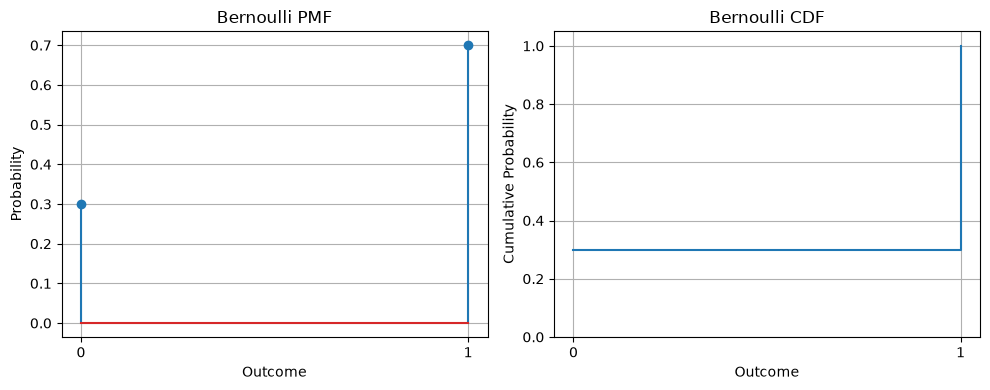

In [36]:
bernoulli = Bernoulli(theta=0.7)
bernoulli.plot()